In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [3]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

'notebook'

In [4]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalDelay',
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'

dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]

HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 320/320 [00:07<00:00, 43.54it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [23]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 88000
PIC electrode count: 68480


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [7]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [8]:
mne.set_log_level('WARNING')
phases = ['Stimulus','Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    # 'ITG','SMG','MTG','IFG','SFG',
                    # 'MFG','STS','AG','SPL','IPL','HG'
                ]))
    &(HGAs.task=='LexicalDelay')
]

# Container for all subjects' trial-level tables
epos = []

for sub in tqdm(subset.subject.unique()):

    this_sub = []

    for phase in phases:
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            onset = dc_epo.events[:, 0] / 2048
            dc_epo.metadata = pd.DataFrame({'onset': onset}, index=dc_epo.selection)
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, scalings={'seeg': 1}, verbose=False)
            meta = dc_epo.metadata.reset_index(names='epoch')  # epoch == selection
            df = df.merge(meta, on='epoch', how='left')

            # drop ch_type column
            df = df.drop(columns=['ch_type'])
            df['phase'] = phase
            df['description'] = condition
            df['subject'] = sub
            df['remark'] = df['condition'].str.split('/').str[4:].str.join('/')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            df['lexical'] = df['condition'].str.split('/').str[0]
            
            # Map lexical values: Word -> Yes, Non-Word -> No
            df['lexical'] = df['lexical'].map({'Word': 'Yes', 'Nonword': 'No'})
            
            this_sub.append(df)
            
    # Concatenate all phases for this subject and extract RT
    this_sub = pd.concat(this_sub, ignore_index=True)
    epos.append(this_sub)

# Concatenate across subjects (optional)
epos = pd.concat(epos, ignore_index=True)
# drop epoch column
epos = epos.drop(columns=['epoch'])

# drop the Stimulus/Response Phase since it's not usable in the RT analysis
# epos = epos[~epos.phase.isin(['Stimulus','Response'])]

epos.head()

100%|██████████| 36/36 [14:12<00:00, 23.69s/it]


,condition,time,channel,value,onset,phase,description,subject,remark,lexical
0,Word/latin,-1.0,D0023_R2IF1-2,-0.705476,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes
1,Word/latin,-1.0,D0023_R2MF10-11,-0.053457,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes
2,Word/latin,-1.0,D0023_R2MF9-10,-0.130285,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes
3,Word/latin,-1.0,D0023_R1MF14-15,0.367956,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes
4,Word/latin,-1.0,D0023_R2MF1-2,-0.105309,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes


In [14]:
cord = HGAs[['channel','label','roi','x','y','z','hemi']].drop_duplicates().reset_index(drop=True)
cord.head()

,channel,label,roi,x,y,z,hemi
0,D0023_RPIF3-4,Intersection,Intersection,41.901912,-28.228735,17.149502,R
1,D0023_R2MF2-3,Intersection,Intersection,11.195341,-7.769187,33.884895,R
2,D0023_RPSF1-2,ctx_rh_S_pericallosal,CGs,6.423360,-15.496811,23.453189,R
3,D0023_RPIF1-2,ctx_rh_Lat_Fis-post,Sylvian,35.187262,-26.860379,15.945394,R
4,D0023_RPIF2-3,ctx_rh_Lat_Fis-post,Sylvian,38.280793,-27.303607,16.525972,R


In [15]:
epos_ = epos.merge(
    cord,
    on='channel',
    how='left'
)
epos_.head()

,condition,time,channel,value,onset,phase,description,subject,remark,lexical,label,roi,x,y,z,hemi
0,Word/latin,-1.0,D0023_R2IF1-2,-0.705476,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_S_circular_insula_sup,PIC,33.089530,-8.192050,18.614382,R
1,Word/latin,-1.0,D0023_R2MF10-11,-0.053457,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_S_precentral-inf-part,SMC,40.025482,-8.423863,36.077959,R
2,Word/latin,-1.0,D0023_R2MF9-10,-0.130285,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_S_precentral-inf-part,SMC,36.417728,-8.358371,36.078040,R
3,Word/latin,-1.0,D0023_R1MF14-15,0.367956,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_precentral,SMC,56.249805,1.672702,35.132438,R
4,Word/latin,-1.0,D0023_R2MF1-2,-0.105309,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Ant,dACC,7.071022,-7.307247,33.304338,R


In [20]:
epos_['lexical'] = epos_['lexical'].map({'Yes': 'Word', 'No': 'Nonword'})

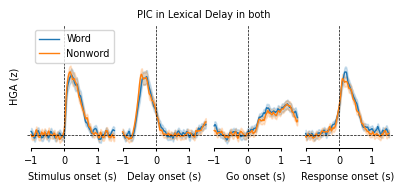

In [29]:
colors = [red, blue]
rois = ['PIC']
condition = 'Decision'

condition = 'both'
subset = epos_[
    (epos_.roi.isin(rois))
    & (epos_.hemi=='L')
    # & (epos_.description==condition)
    & (epos_.remark=='CORRECT')
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['Stimulus', 'Delay', 'Go', 'Response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='lexical',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.1, 1)


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle(rois[0] + ' in Lexical Delay in ' + condition, fontsize=7)
plt.savefig(f'../img/misc/lexical_{rois[0]}_{condition}_lexicality_difference.svg', dpi=300, bbox_inches='tight')

plt.show()